In [2]:
# Importing all the modules and packages required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
#Reading my csv file
df = pd.read_csv("../economic_index.csv")

In [4]:
#Checking my dataframe
df

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [5]:
#Check the data for misssing values
df.isnull().sum()

Unnamed: 0           0
year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [6]:
#Finding the co-relation between the features
df.corr()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
Unnamed: 0,1.000000,-8.667781e-01,-4.986939e-01,-0.934555,0.935300,-0.988246
year,-0.866778,1.000000e+00,7.887056e-14,0.882851,-0.877000,0.863232
month,-0.498694,7.887056e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,-0.934555,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,0.935300,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,-0.988246,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


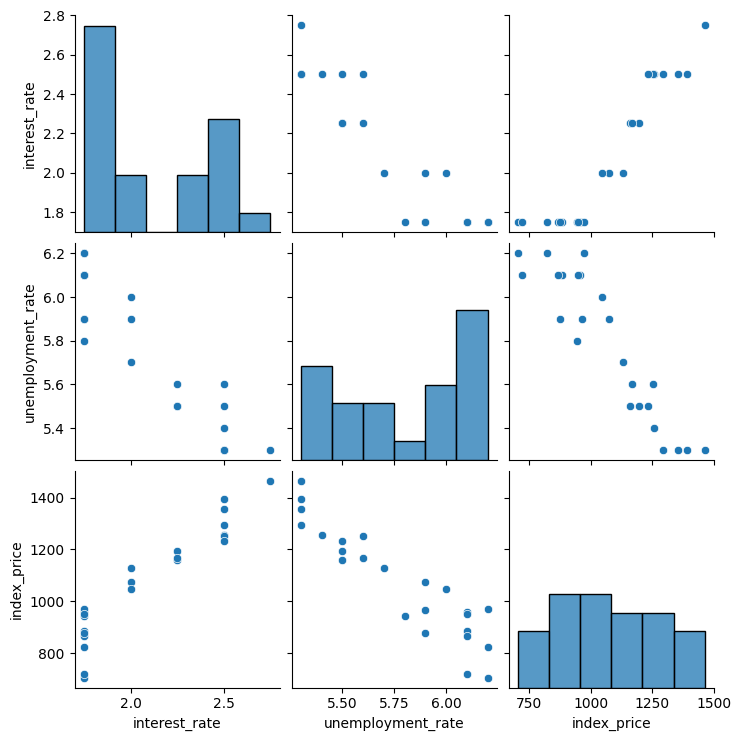

In [7]:
sns.pairplot(df[['interest_rate','unemployment_rate','index_price']])

In [8]:
# Separating the features and not important features
X = df[[ 'interest_rate', 'unemployment_rate']]

In [9]:
y = df[['index_price']]

In [10]:
X.shape

(24, 2)

In [11]:
y.shape

(24, 1)

<Axes: xlabel='interest_rate', ylabel='index_price'>

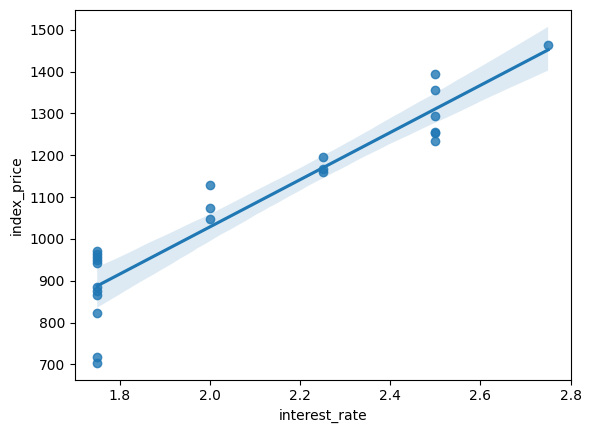

In [12]:
sns.regplot(x=df['interest_rate'], y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

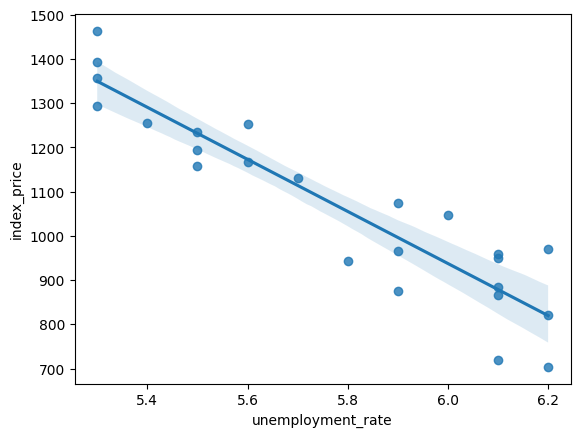

In [13]:
sns.regplot(x = df['unemployment_rate'], y=df['index_price'])

In [14]:
# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [15]:
# Creaing a scaler object using StandardScaler()
scaler = StandardScaler()

In [16]:
# After spliting the data, we fit_transform the data
X_train = scaler.fit_transform(X_train)

In [17]:
X_test = scaler.transform(X_test)

In [18]:
#Creating regression model
regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
#Something new - Cross validation

from sklearn.model_selection import cross_val_score
validation_scores = cross_val_score(regression, X_train, y_train, scoring= 'neg_root_mean_squared_error', cv = 5)

In [20]:
validation_scores

array([ -50.28779187,  -55.38612828, -111.05537851,  -48.45565949,
       -102.78948715])

In [21]:
y_pred = regression.predict(X_test)

In [22]:
#Evaluation Metrics


In [23]:
score = r2_score(y_test, y_pred)

In [24]:
print(score)

0.9258156632126227


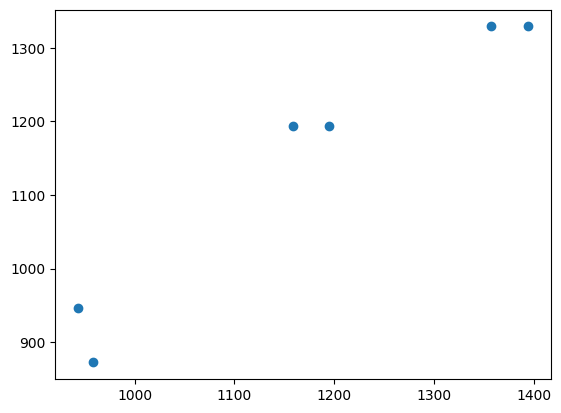

In [25]:
plt.scatter(y_test, y_pred)

In [26]:
residuals = y_test-y_pred

In [27]:
residuals

,index_price
7,1.613897
15,85.783686
8,-34.386103
2,27.790030
1,64.790030
14,-3.499396


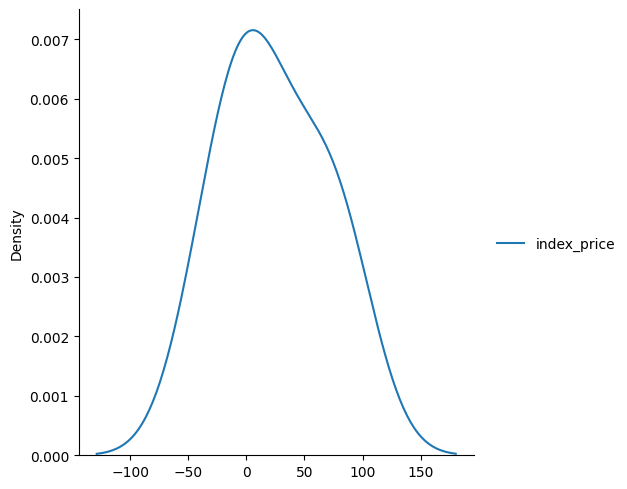

In [28]:
sns.displot(residuals, kind = 'kde')

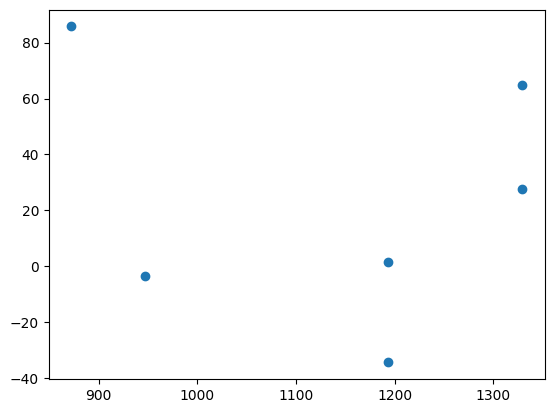

In [30]:
plt.scatter(y_pred, residuals)

In [31]:
X_train

array([[ 1.32424438, -1.41865309],
       [-0.84270097,  0.8440088 ],
       [-0.12038585, -0.44894085],
       [ 0.60192927, -0.77217826],
       [-0.84270097,  0.19753397],
       [-0.84270097,  1.16724621],
       [-0.12038585,  0.19753397],
       [ 1.32424438, -1.7418905 ],
       [ 1.32424438, -1.09541568],
       [-0.84270097,  0.8440088 ],
       [-0.12038585,  0.52077139],
       [-0.84270097,  1.16724621],
       [-0.84270097,  0.19753397],
       [ 1.32424438, -0.77217826],
       [ 2.0465595 , -1.7418905 ],
       [-0.84270097,  0.8440088 ],
       [-0.84270097,  1.16724621],
       [-0.84270097,  0.8440088 ]])

In [36]:
testing = [[2.75, 5.3]]

In [37]:
regression.predict(scaler.transform(testing))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[1415.51178248]])